# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 28: STRUCTURED MULTI-LABEL DECODING IMPROVEMENT
# ============================================================
# Purpose:
# This notebook improves the structured multi-label candidate-150
# baseline by testing better decoding strategies.
#
# The goal is to:
# 1. Load saved validation and test score matrices
# 2. Compare global threshold decoding, per-label thresholding,
#    and top-k decoding
# 3. Select the best validation-time decoding strategy
# 4. Apply the best decoding strategy to the test set
# 5. Save the improved structured multi-label results
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    f1_score,
    hamming_loss,
    accuracy_score,
    precision_score,
    recall_score
)

In [2]:
# ============================================================
# 2. LOAD SAVED OUTPUTS
# ============================================================

val_scores = np.load("../data/processed/structured_multilabel_candidate150_val_scores.npy")
test_scores = np.load("../data/processed/structured_multilabel_candidate150_test_scores.npy")

Y_val = np.load("../data/processed/structured_multilabel_candidate150_y_val.npy")
Y_test = np.load("../data/processed/structured_multilabel_candidate150_y_test.npy")

label_cols = np.load(
    "../data/processed/structured_multilabel_candidate150_label_columns.npy",
    allow_pickle=True
)

with open("../data/processed/best_structured_multilabel_candidate150_name.txt", "r") as f:
    best_model_name = f.read().strip()

with open("../data/processed/structured_multilabel_candidate150_best_threshold.txt", "r") as f:
    tuned_global_threshold = float(f.read().strip())

print("Best model:", best_model_name)
print("Validation score matrix shape:", val_scores.shape)
print("Test score matrix shape:", test_scores.shape)
print("Y_val shape:", Y_val.shape)
print("Y_test shape:", Y_test.shape)
print("Number of labels:", len(label_cols))
print("Best global threshold from Notebook 27:", tuned_global_threshold)

Best model: OVR SGD Hinge
Validation score matrix shape: (5000, 150)
Test score matrix shape: (5000, 150)
Y_val shape: (5000, 150)
Y_test shape: (5000, 150)
Number of labels: 150
Best global threshold from Notebook 27: -1.0


In [3]:
# ============================================================
# 3. DEFINE EVALUATION HELPERS
# ============================================================

def evaluate_multilabel(y_true, y_pred, name="Model"):
    return {
        "Model": name,
        "Micro F1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Samples F1": f1_score(y_true, y_pred, average="samples", zero_division=0),
        "Micro Precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "Micro Recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "Hamming Loss": hamming_loss(y_true, y_pred),
        "Subset Accuracy": accuracy_score(y_true, y_pred),
        "Avg Predicted Labels": float(y_pred.sum(axis=1).mean())
    }

def precision_recall_at_k(y_true, score_matrix, k=3):
    y_true = np.asarray(y_true)
    topk_idx = np.argsort(-score_matrix, axis=1)[:, :k]

    precision_vals = []
    recall_vals = []

    for i in range(y_true.shape[0]):
        true_idx = np.where(y_true[i] == 1)[0]
        if len(true_idx) == 0:
            continue

        pred_idx = topk_idx[i]
        hits = len(set(pred_idx).intersection(set(true_idx)))

        precision_vals.append(hits / k)
        recall_vals.append(hits / len(true_idx))

    return float(np.mean(precision_vals)), float(np.mean(recall_vals))

In [4]:
# ============================================================
# 4. DECODING HELPERS
# ============================================================

def decode_global_threshold(score_matrix, threshold):
    return (score_matrix >= threshold).astype(np.uint8)

def decode_top_k(score_matrix, k):
    y_pred = np.zeros_like(score_matrix, dtype=np.uint8)
    topk_idx = np.argsort(-score_matrix, axis=1)[:, :k]

    for i in range(score_matrix.shape[0]):
        y_pred[i, topk_idx[i]] = 1

    return y_pred

def decode_per_label_threshold(score_matrix, thresholds):
    y_pred = np.zeros_like(score_matrix, dtype=np.uint8)

    for j in range(score_matrix.shape[1]):
        y_pred[:, j] = (score_matrix[:, j] >= thresholds[j]).astype(np.uint8)

    return y_pred

def decode_top_k_with_min_threshold(score_matrix, k, threshold):
    y_pred = np.zeros_like(score_matrix, dtype=np.uint8)
    topk_idx = np.argsort(-score_matrix, axis=1)[:, :k]

    for i in range(score_matrix.shape[0]):
        chosen = []
        for idx in topk_idx[i]:
            if score_matrix[i, idx] >= threshold:
                chosen.append(idx)

        if len(chosen) == 0:
            chosen = [topk_idx[i][0]]

        y_pred[i, chosen] = 1

    return y_pred

In [5]:
# ============================================================
# 5. BASELINE: GLOBAL THRESHOLD RESULTS
# ============================================================

Y_val_pred_global = decode_global_threshold(val_scores, tuned_global_threshold)
Y_test_pred_global = decode_global_threshold(test_scores, tuned_global_threshold)

global_val_results = evaluate_multilabel(
    Y_val,
    Y_val_pred_global,
    name=f"Global Threshold ({tuned_global_threshold:.2f})"
)

global_test_results = evaluate_multilabel(
    Y_test,
    Y_test_pred_global,
    name=f"Global Threshold ({tuned_global_threshold:.2f})"
)

p3_val, r3_val = precision_recall_at_k(Y_val, val_scores, k=3)
p5_val, r5_val = precision_recall_at_k(Y_val, val_scores, k=5)

global_val_results["Precision@3"] = p3_val
global_val_results["Recall@3"] = r3_val
global_val_results["Precision@5"] = p5_val
global_val_results["Recall@5"] = r5_val

p3_test, r3_test = precision_recall_at_k(Y_test, test_scores, k=3)
p5_test, r5_test = precision_recall_at_k(Y_test, test_scores, k=5)

global_test_results["Precision@3"] = p3_test
global_test_results["Recall@3"] = r3_test
global_test_results["Precision@5"] = p5_test
global_test_results["Recall@5"] = r5_test

print("Global threshold validation results:")
print(global_val_results)

Global threshold validation results:
{'Model': 'Global Threshold (-1.00)', 'Micro F1': 0.16579583330254008, 'Macro F1': 0.079174426693012, 'Samples F1': 0.16628964673475166, 'Micro Precision': 0.09687532386775832, 'Micro Recall': 0.5745530912257337, 'Hamming Loss': 0.15050266666666667, 'Subset Accuracy': 0.0, 'Avg Predicted Labels': 23.1576, 'Precision@3': 0.02493333333333333, 'Recall@3': 0.01941611111111111, 'Precision@5': 0.03, 'Recall@5': 0.03788651515151515}


In [6]:
# ============================================================
# 5. BASELINE: GLOBAL THRESHOLD RESULTS
# ============================================================

Y_val_pred_global = decode_global_threshold(val_scores, tuned_global_threshold)
Y_test_pred_global = decode_global_threshold(test_scores, tuned_global_threshold)

global_val_results = evaluate_multilabel(
    Y_val,
    Y_val_pred_global,
    name=f"Global Threshold ({tuned_global_threshold:.2f})"
)

global_test_results = evaluate_multilabel(
    Y_test,
    Y_test_pred_global,
    name=f"Global Threshold ({tuned_global_threshold:.2f})"
)

p3_val, r3_val = precision_recall_at_k(Y_val, val_scores, k=3)
p5_val, r5_val = precision_recall_at_k(Y_val, val_scores, k=5)

global_val_results["Precision@3"] = p3_val
global_val_results["Recall@3"] = r3_val
global_val_results["Precision@5"] = p5_val
global_val_results["Recall@5"] = r5_val

p3_test, r3_test = precision_recall_at_k(Y_test, test_scores, k=3)
p5_test, r5_test = precision_recall_at_k(Y_test, test_scores, k=5)

global_test_results["Precision@3"] = p3_test
global_test_results["Recall@3"] = r3_test
global_test_results["Precision@5"] = p5_test
global_test_results["Recall@5"] = r5_test

print("Global threshold validation results:")
print(global_val_results)

Global threshold validation results:
{'Model': 'Global Threshold (-1.00)', 'Micro F1': 0.16579583330254008, 'Macro F1': 0.079174426693012, 'Samples F1': 0.16628964673475166, 'Micro Precision': 0.09687532386775832, 'Micro Recall': 0.5745530912257337, 'Hamming Loss': 0.15050266666666667, 'Subset Accuracy': 0.0, 'Avg Predicted Labels': 23.1576, 'Precision@3': 0.02493333333333333, 'Recall@3': 0.01941611111111111, 'Precision@5': 0.03, 'Recall@5': 0.03788651515151515}


In [7]:
# ============================================================
# 6. TOP-K DECODING SEARCH
# ============================================================

topk_results = []

for k in [1, 2, 3, 4, 5, 6]:
    Y_val_pred_k = decode_top_k(val_scores, k)

    results = evaluate_multilabel(Y_val, Y_val_pred_k, name=f"Top-{k}")
    p3, r3 = precision_recall_at_k(Y_val, val_scores, k=3)
    p5, r5 = precision_recall_at_k(Y_val, val_scores, k=5)

    results["Precision@3"] = p3
    results["Recall@3"] = r3
    results["Precision@5"] = p5
    results["Recall@5"] = r5
    results["k"] = k

    topk_results.append(results)

topk_results_df = pd.DataFrame(topk_results).sort_values("Micro F1", ascending=False).reset_index(drop=True)

print("Top-k decoding results:")
display(topk_results_df)

Top-k decoding results:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Precision@3,Recall@3,Precision@5,Recall@5,k
0,Top-6,0.039416,0.044418,0.037475,0.032533,0.049992,0.063428,0.0000,6.0,0.024933,0.019416,0.03,0.037887,6
1,Top-5,0.033690,0.040632,0.032063,0.030000,0.038416,0.057364,0.0000,5.0,0.024933,0.019416,0.03,0.037887,5
2,Top-4,0.027579,0.035940,0.026424,0.027250,0.027916,0.051244,0.0000,4.0,0.024933,0.019416,0.03,0.037887,4
3,Top-3,0.021667,0.031833,0.020826,0.024933,0.019157,0.045033,0.0000,3.0,0.024933,0.019416,0.03,0.037887,3
4,Top-2,0.014633,0.026789,0.014212,0.021600,0.011064,0.038788,0.0000,2.0,0.024933,0.019416,0.03,0.037887,2
5,Top-1,0.008319,0.020992,0.008094,0.020400,0.005225,0.032425,0.0002,1.0,0.024933,0.019416,0.03,0.037887,1


In [8]:
# ============================================================
# 7. TOP-K PLUS THRESHOLD SEARCH
# ============================================================

hybrid_decode_results = []

for k in [3, 4, 5, 6]:
    for threshold in [-1.0, -0.5, 0.0, 0.5]:
        Y_val_pred_hybrid = decode_top_k_with_min_threshold(val_scores, k=k, threshold=threshold)

        results = evaluate_multilabel(
            Y_val,
            Y_val_pred_hybrid,
            name=f"Top-{k} + Threshold {threshold:.2f}"
        )

        results["k"] = k
        results["Threshold"] = threshold

        hybrid_decode_results.append(results)

hybrid_decode_results_df = pd.DataFrame(hybrid_decode_results).sort_values("Micro F1", ascending=False).reset_index(drop=True)

print("Top-k plus threshold results:")
display(hybrid_decode_results_df.head(20))

Top-k plus threshold results:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,k,Threshold
0,Top-6 + Threshold 0.50,0.039418,0.044419,0.037481,0.032536,0.049992,0.063425,0.0,5.9996,6,0.5
1,Top-6 + Threshold -0.50,0.039416,0.044418,0.037475,0.032533,0.049992,0.063428,0.0,6.0000,6,-0.5
2,Top-6 + Threshold 0.00,0.039416,0.044418,0.037475,0.032533,0.049992,0.063428,0.0,6.0000,6,0.0
3,Top-6 + Threshold -1.00,0.039416,0.044418,0.037475,0.032533,0.049992,0.063428,0.0,6.0000,6,-1.0
4,Top-5 + Threshold 0.50,0.033691,0.040633,0.032067,0.030001,0.038416,0.057363,0.0,4.9998,5,0.5
5,Top-5 + Threshold -0.50,0.033690,0.040632,0.032063,0.030000,0.038416,0.057364,0.0,5.0000,5,-0.5
6,Top-5 + Threshold 0.00,0.033690,0.040632,0.032063,0.030000,0.038416,0.057364,0.0,5.0000,5,0.0
7,Top-5 + Threshold -1.00,0.033690,0.040632,0.032063,0.030000,0.038416,0.057364,0.0,5.0000,5,-1.0
8,Top-4 + Threshold -1.00,0.027579,0.035940,0.026424,0.027250,0.027916,0.051244,0.0,4.0000,4,-1.0
9,Top-4 + Threshold -0.50,0.027579,0.035940,0.026424,0.027250,0.027916,0.051244,0.0,4.0000,4,-0.5


In [9]:
# ============================================================
# 8. PER-LABEL THRESHOLD SEARCH
# ============================================================
# For each label, choose the threshold that gives the best
# binary F1 on the validation set.

if best_model_name == "OVR SGD Hinge":
    per_label_grid = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])
else:
    per_label_grid = np.array([0.1, 0.3, 0.5, 0.7, 0.9])

best_thresholds_per_label = np.zeros(val_scores.shape[1], dtype=np.float32)

for j in range(val_scores.shape[1]):
    y_true_j = Y_val[:, j]
    scores_j = val_scores[:, j]

    best_f1_j = -1.0
    best_t_j = per_label_grid[0]

    for t in per_label_grid:
        y_pred_j = (scores_j >= t).astype(np.uint8)
        f1_j = f1_score(y_true_j, y_pred_j, zero_division=0)

        if f1_j > best_f1_j:
            best_f1_j = f1_j
            best_t_j = t

    best_thresholds_per_label[j] = best_t_j

print("Per-label thresholds learned.")
print("Unique chosen thresholds:", np.unique(best_thresholds_per_label))

Per-label thresholds learned.
Unique chosen thresholds: [-1.  -0.5  0.   0.5  1. ]


In [10]:
# ============================================================
# 8. PER-LABEL THRESHOLD SEARCH
# ============================================================
# For each label, choose the threshold that gives the best
# binary F1 on the validation set.

if best_model_name == "OVR SGD Hinge":
    per_label_grid = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])
else:
    per_label_grid = np.array([0.1, 0.3, 0.5, 0.7, 0.9])

best_thresholds_per_label = np.zeros(val_scores.shape[1], dtype=np.float32)

for j in range(val_scores.shape[1]):
    y_true_j = Y_val[:, j]
    scores_j = val_scores[:, j]

    best_f1_j = -1.0
    best_t_j = per_label_grid[0]

    for t in per_label_grid:
        y_pred_j = (scores_j >= t).astype(np.uint8)
        f1_j = f1_score(y_true_j, y_pred_j, zero_division=0)

        if f1_j > best_f1_j:
            best_f1_j = f1_j
            best_t_j = t

    best_thresholds_per_label[j] = best_t_j

print("Per-label thresholds learned.")
print("Unique chosen thresholds:", np.unique(best_thresholds_per_label))

Per-label thresholds learned.
Unique chosen thresholds: [-1.  -0.5  0.   0.5  1. ]


In [11]:
# ============================================================
# 9. EVALUATE PER-LABEL THRESHOLD DECODING
# ============================================================

Y_val_pred_per_label = decode_per_label_threshold(val_scores, best_thresholds_per_label)
Y_test_pred_per_label = decode_per_label_threshold(test_scores, best_thresholds_per_label)

per_label_val_results = evaluate_multilabel(
    Y_val,
    Y_val_pred_per_label,
    name="Per-Label Thresholds"
)

per_label_test_results = evaluate_multilabel(
    Y_test,
    Y_test_pred_per_label,
    name="Per-Label Thresholds"
)

p3_val_pl, r3_val_pl = precision_recall_at_k(Y_val, val_scores, k=3)
p5_val_pl, r5_val_pl = precision_recall_at_k(Y_val, val_scores, k=5)

per_label_val_results["Precision@3"] = p3_val_pl
per_label_val_results["Recall@3"] = r3_val_pl
per_label_val_results["Precision@5"] = p5_val_pl
per_label_val_results["Recall@5"] = r5_val_pl

p3_test_pl, r3_test_pl = precision_recall_at_k(Y_test, test_scores, k=3)
p5_test_pl, r5_test_pl = precision_recall_at_k(Y_test, test_scores, k=5)

per_label_test_results["Precision@3"] = p3_test_pl
per_label_test_results["Recall@3"] = r3_test_pl
per_label_test_results["Precision@5"] = p5_test_pl
per_label_test_results["Recall@5"] = r5_test_pl

print("Per-label threshold validation results:")
print(per_label_val_results)

Per-label threshold validation results:
{'Model': 'Per-Label Thresholds', 'Micro F1': 0.1664076634910625, 'Macro F1': 0.07973137755338032, 'Samples F1': 0.16676633907593386, 'Micro Precision': 0.09749296270232231, 'Micro Recall': 0.5676893919991804, 'Hamming Loss': 0.14804933333333334, 'Subset Accuracy': 0.0, 'Avg Predicted Labels': 22.736, 'Precision@3': 0.02493333333333333, 'Recall@3': 0.01941611111111111, 'Precision@5': 0.03, 'Recall@5': 0.03788651515151515}


In [12]:
# ============================================================
# 10. SELECT BEST VALIDATION DECODING STRATEGY
# ============================================================

best_topk_row = topk_results_df.iloc[0].to_dict()
best_hybrid_row = hybrid_decode_results_df.iloc[0].to_dict()

comparison_validation_df = pd.DataFrame([
    global_val_results,
    best_topk_row,
    best_hybrid_row,
    per_label_val_results
])

comparison_validation_df = comparison_validation_df.sort_values("Micro F1", ascending=False).reset_index(drop=True)

print("Validation decoding strategy comparison:")
display(comparison_validation_df)

Validation decoding strategy comparison:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Precision@3,Recall@3,Precision@5,Recall@5,k,Threshold
0,Per-Label Thresholds,0.166408,0.079731,0.166766,0.097493,0.567689,0.148049,0.0,22.7360,0.024933,0.019416,0.03,0.037887,NaN,NaN
1,Global Threshold (-1.00),0.165796,0.079174,0.166290,0.096875,0.574553,0.150503,0.0,23.1576,0.024933,0.019416,0.03,0.037887,NaN,NaN
2,Top-6 + Threshold 0.50,0.039418,0.044419,0.037481,0.032536,0.049992,0.063425,0.0,5.9996,NaN,NaN,NaN,NaN,6.0,0.5
3,Top-6,0.039416,0.044418,0.037475,0.032533,0.049992,0.063428,0.0,6.0000,0.024933,0.019416,0.03,0.037887,6.0,NaN


In [13]:
# ============================================================
# 11. APPLY BEST STRATEGY TO TEST
# ============================================================

best_strategy_name = comparison_validation_df.iloc[0]["Model"]
print("Best decoding strategy:", best_strategy_name)

if best_strategy_name.startswith("Global Threshold"):
    final_test_results = global_test_results
    final_test_pred = Y_test_pred_global

elif best_strategy_name.startswith("Top-") and "Threshold" not in best_strategy_name:
    best_k = int(comparison_validation_df.iloc[0]["k"])
    final_test_pred = decode_top_k(test_scores, best_k)
    final_test_results = evaluate_multilabel(Y_test, final_test_pred, name=best_strategy_name)

elif best_strategy_name.startswith("Top-") and "Threshold" in best_strategy_name:
    best_k = int(comparison_validation_df.iloc[0]["k"])
    best_t = float(comparison_validation_df.iloc[0]["Threshold"])
    final_test_pred = decode_top_k_with_min_threshold(test_scores, best_k, best_t)
    final_test_results = evaluate_multilabel(Y_test, final_test_pred, name=best_strategy_name)

else:
    final_test_results = per_label_test_results
    final_test_pred = Y_test_pred_per_label

p3_final, r3_final = precision_recall_at_k(Y_test, test_scores, k=3)
p5_final, r5_final = precision_recall_at_k(Y_test, test_scores, k=5)

final_test_results["Precision@3"] = p3_final
final_test_results["Recall@3"] = r3_final
final_test_results["Precision@5"] = p5_final
final_test_results["Recall@5"] = r5_final

print("Final selected test results:")
print(final_test_results)

Best decoding strategy: Per-Label Thresholds
Final selected test results:
{'Model': 'Per-Label Thresholds', 'Micro F1': 0.16364778636470295, 'Macro F1': 0.08373009800429386, 'Samples F1': 0.16424733895613516, 'Micro Precision': 0.09511407529937617, 'Micro Recall': 0.585590465872156, 'Hamming Loss': 0.147324, 'Subset Accuracy': 0.0, 'Avg Predicted Labels': 22.7306, 'Precision@3': 0.024866666666666665, 'Recall@3': 0.019935714285714282, 'Precision@5': 0.03196, 'Recall@5': 0.042197460317460314}


In [14]:
# ============================================================
# 12. COMPARE TEST RESULTS
# ============================================================

test_comparison_df = pd.DataFrame([
    global_test_results,
    per_label_test_results,
    final_test_results
]).drop_duplicates(subset=["Model"]).reset_index(drop=True)

print("Test comparison:")
display(test_comparison_df)

Test comparison:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Precision@3,Recall@3,Precision@5,Recall@5
0,Global Threshold (-1.00),0.163624,0.08353,0.164282,0.094862,0.594691,0.149640,0.0,23.1452,0.024867,0.019936,0.03196,0.042197
1,Per-Label Thresholds,0.163648,0.08373,0.164247,0.095114,0.585590,0.147324,0.0,22.7306,0.024867,0.019936,0.03196,0.042197


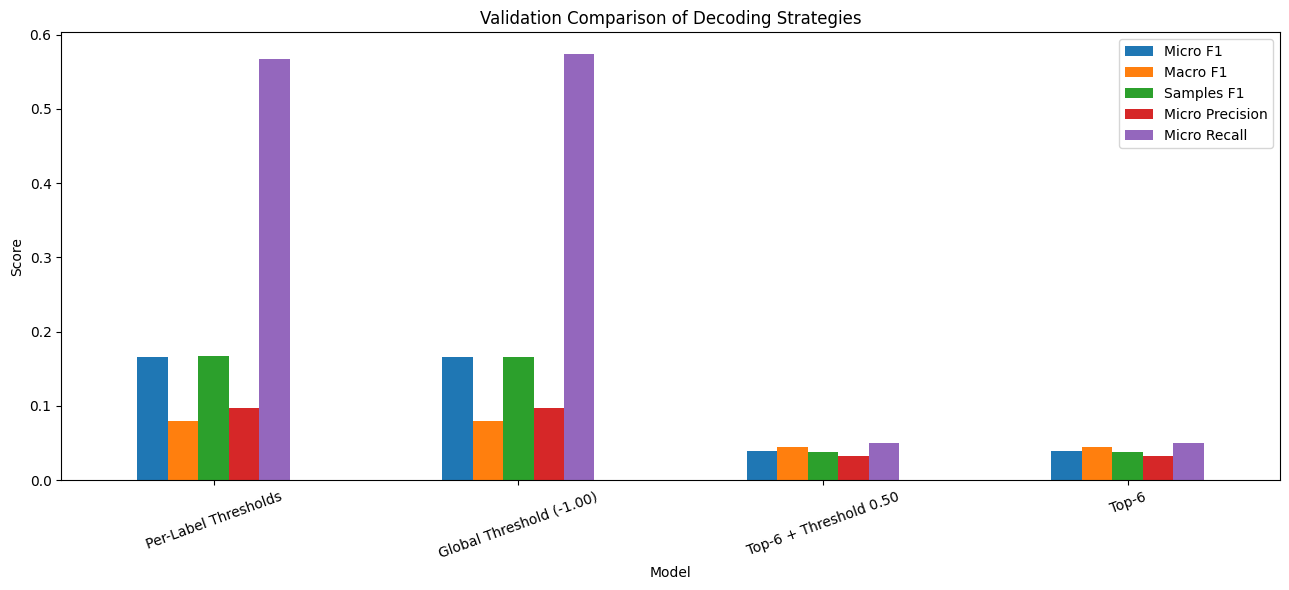

In [15]:
# ============================================================
# 13. PLOT MAIN VALIDATION COMPARISON
# ============================================================

plot_cols = ["Micro F1", "Macro F1", "Samples F1", "Micro Precision", "Micro Recall"]

plot_df = comparison_validation_df.set_index("Model")[plot_cols]

ax = plot_df.plot(kind="bar", figsize=(13, 6))
ax.set_title("Validation Comparison of Decoding Strategies")
ax.set_ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 14. SAVE OUTPUTS
# ============================================================

os.makedirs("../data/processed", exist_ok=True)

topk_results_df.to_csv(
    "../data/processed/structured_multilabel_candidate150_topk_results.csv",
    index=False
)

hybrid_decode_results_df.to_csv(
    "../data/processed/structured_multilabel_candidate150_topk_threshold_results.csv",
    index=False
)

comparison_validation_df.to_csv(
    "../data/processed/structured_multilabel_candidate150_decoding_validation_comparison.csv",
    index=False
)

test_comparison_df.to_csv(
    "../data/processed/structured_multilabel_candidate150_decoding_test_comparison.csv",
    index=False
)

np.save(
    "../data/processed/structured_multilabel_candidate150_per_label_thresholds.npy",
    best_thresholds_per_label
)

np.save(
    "../data/processed/structured_multilabel_candidate150_final_test_pred.npy",
    final_test_pred
)

with open("../data/processed/structured_multilabel_candidate150_best_decoding_strategy.txt", "w") as f:
    f.write(str(best_strategy_name))

print("Saved structured multi-label decoding improvement outputs.")

Saved structured multi-label decoding improvement outputs.


In [17]:
# ============================================================
# 15. INTERPRETATION NOTES
# ============================================================

print("1. This notebook improves the structured multi-label baseline by testing better decoding strategies.")
print("2. The core issue being addressed is over-prediction of labels.")
print("3. Top-k and per-label thresholding are often more realistic for large multi-label problems than a single global threshold.")
print("4. The selected decoding strategy becomes the improved structured baseline for the next project phase.")
print("5. After this step, the next decision will be whether to move into audio multi-label modelling or do one more structured model upgrade.")

1. This notebook improves the structured multi-label baseline by testing better decoding strategies.
2. The core issue being addressed is over-prediction of labels.
3. Top-k and per-label thresholding are often more realistic for large multi-label problems than a single global threshold.
4. The selected decoding strategy becomes the improved structured baseline for the next project phase.
5. After this step, the next decision will be whether to move into audio multi-label modelling or do one more structured model upgrade.
